# Phase 1 — EDA & Preprocessing
## Sentiment Analysis on Twitter (Sentiment140)

### Topic Description
This project focuses on **sentiment analysis of social media posts (Twitter)** — classifying tweets
as positive or negative. Understanding public sentiment on social networks has applications in
brand monitoring, political analysis, event tracking, and more.

### Dataset
**Source:** `training.1600000.processed.noemoticon.csv` (Sentiment140) — 1.6M tweets auto-labeled using emoticons:
- **0** — Negative sentiment
- **4** — Positive sentiment

### This Notebook Covers
1. Loading & inspecting the data
2. Statistical analysis (EDA)
3. Word frequency analysis & word clouds
4. Temporal analysis
5. User activity analysis
6. Preprocessing pipeline
7. Vectorization (TF-IDF)

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'pandas', 'matplotlib', 'seaborn', 'wordcloud',
                'nltk', 'scikit-learn'])
print('Dependencies installed.')

Dependencies installed.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import string
from collections import Counter

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()

print('All imports ready.')

All imports ready.


---
## 1. Load & Inspect the Data

In [3]:
columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']
df_full = pd.read_csv('../data-sets/training.1600000.processed.noemoticon.csv',
                       encoding='latin-1', header=None, names=columns)

print(f'Full dataset shape: {df_full.shape}')
print(f'Columns: {list(df_full.columns)}')
print(f'\nSentiment value counts (full):')
print(df_full['sentiment'].value_counts().sort_index())
df_full.head()

Full dataset shape: (1600000, 6)
Columns: ['sentiment', 'id', 'date', 'query', 'user', 'text']

Sentiment value counts (full):
sentiment
0    800000
4    800000
Name: count, dtype: int64


,sentiment,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [4]:
# Sample 50K for EDA (balanced: 25K per class)
SAMPLE_SIZE = 25000
df = pd.concat([
    df_full[df_full['sentiment'] == 0].sample(SAMPLE_SIZE, random_state=42),
    df_full[df_full['sentiment'] == 4].sample(SAMPLE_SIZE, random_state=42)
]).reset_index(drop=True)

df['sentiment_label'] = df['sentiment'].map({0: 'Negative', 4: 'Positive'})

print(f'Sample size for EDA: {len(df):,}')
print(df['sentiment_label'].value_counts())
print(f'\nMissing values:')
print(df.isnull().sum())
print(f'\nDuplicate texts: {df["text"].duplicated().sum()}')

Sample size for EDA: 50,000
sentiment_label
Negative    25000
Positive    25000
Name: count, dtype: int64

Missing values:
sentiment          0
id                 0
date               0
query              0
user               0
text               0
sentiment_label    0
dtype: int64

Duplicate texts: 101


---
## 2. Class Distribution

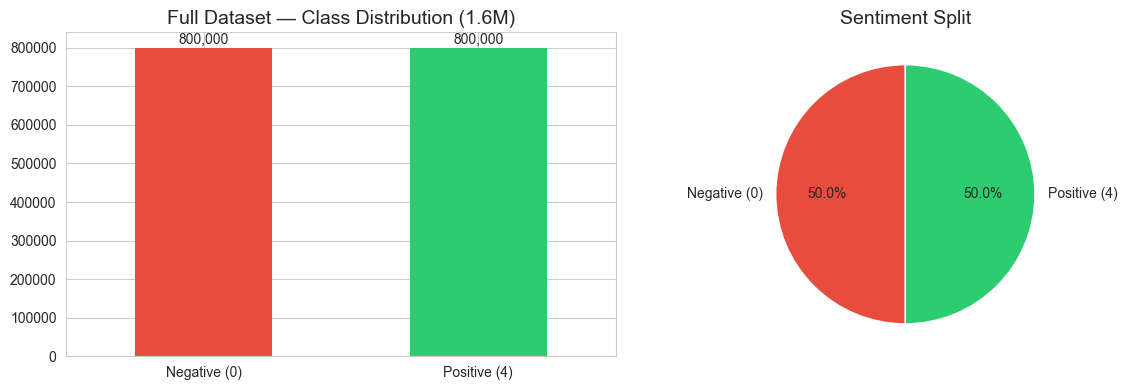

** The dataset is perfectly balanced — 800K tweets per class. **


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#e74c3c', '#2ecc71']

# Full dataset distribution
full_counts = df_full['sentiment'].value_counts().sort_index()
full_counts.index = ['Negative (0)', 'Positive (4)']
full_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='none')
axes[0].set_title('Full Dataset — Class Distribution (1.6M)', fontsize=14)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(full_counts):
    axes[0].text(i, v + 10000, f'{v:,}', ha='center', fontsize=10)

axes[1].pie(full_counts, labels=full_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Sentiment Split', fontsize=14)

plt.tight_layout()
plt.show()

print('** The dataset is perfectly balanced — 800K tweets per class. **')

---
## 3. Text Statistics

In [6]:
df['char_count'] = df['text'].astype(str).apply(len)
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))
df['url_count'] = df['text'].astype(str).apply(lambda x: len(re.findall(r'http\S+', x)))
df['mention_count'] = df['text'].astype(str).apply(lambda x: len(re.findall(r'@\w+', x)))
df['hashtag_count'] = df['text'].astype(str).apply(lambda x: len(re.findall(r'#\w+', x)))
df['exclamation_count'] = df['text'].astype(str).apply(lambda x: x.count('!'))
df['question_count'] = df['text'].astype(str).apply(lambda x: x.count('?'))
df['special_char_count'] = df['text'].astype(str).apply(
    lambda x: sum(1 for c in x if c in string.punctuation))

stats_cols = ['char_count', 'word_count', 'url_count', 'mention_count',
              'hashtag_count', 'exclamation_count', 'question_count', 'special_char_count']
print('Overall text statistics (50K sample):')
df[stats_cols].describe().round(1)

Overall text statistics (50K sample):


,char_count,word_count,url_count,mention_count,hashtag_count,exclamation_count,question_count,special_char_count
count,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0
mean,74.0,13.1,0.0,0.5,0.0,0.6,0.2,4.0
std,36.4,7.0,0.2,0.6,0.2,1.4,1.1,3.5
min,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,44.0,7.0,0.0,0.0,0.0,0.0,0.0,2.0
50%,69.0,12.0,0.0,0.0,0.0,0.0,0.0,3.0
75%,103.0,18.0,0.0,1.0,0.0,1.0,0.0,6.0
max,282.0,41.0,3.0,9.0,10.0,98.0,110.0,111.0


In [7]:
print('Text statistics by sentiment:')
df.groupby('sentiment_label')[stats_cols].mean().round(1)

Text statistics by sentiment:


,char_count,word_count,url_count,mention_count,hashtag_count,exclamation_count,question_count,special_char_count
sentiment_label,,,,,,,,
Negative,74.2,13.6,0.0,0.4,0.0,0.5,0.2,3.8
Positive,73.7,12.7,0.1,0.6,0.0,0.7,0.2,4.2


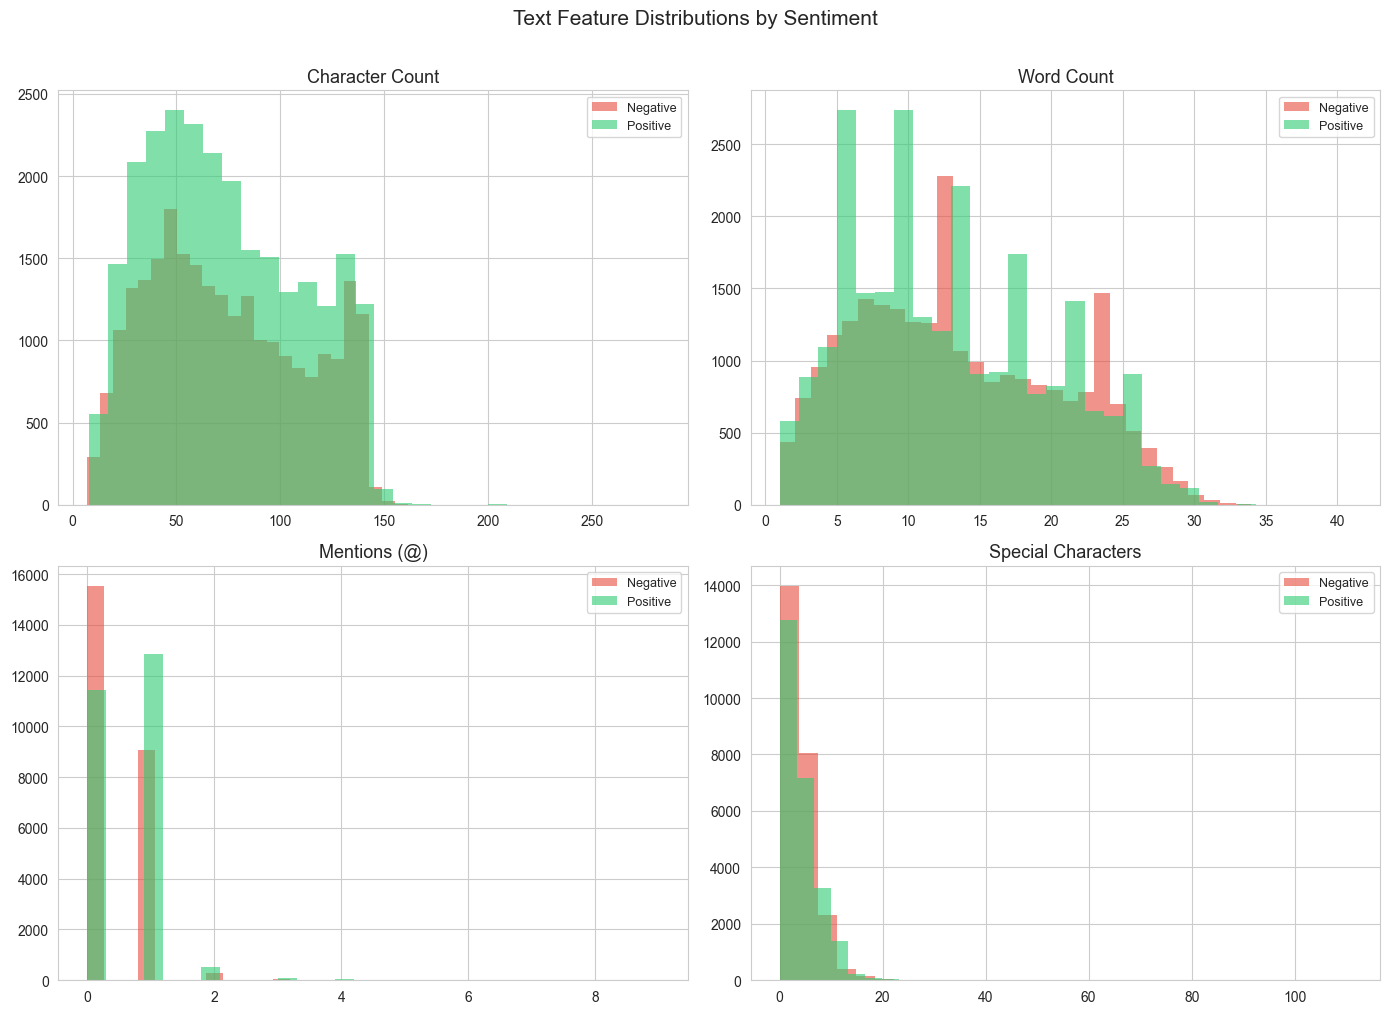

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col, title in zip(axes.flat,
    ['char_count', 'word_count', 'mention_count', 'special_char_count'],
    ['Character Count', 'Word Count', 'Mentions (@)', 'Special Characters']):
    for label, color in zip(['Negative', 'Positive'], colors):
        subset = df[df['sentiment_label'] == label][col]
        ax.hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor='none')
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9)

plt.suptitle('Text Feature Distributions by Sentiment', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

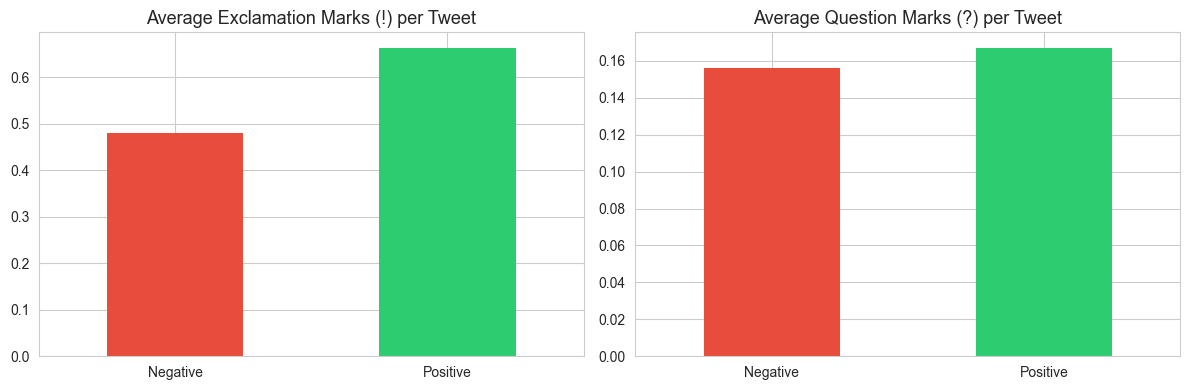

In [9]:
# Exclamation and question mark usage by sentiment
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(axes,
    ['exclamation_count', 'question_count'],
    ['Exclamation Marks (!)', 'Question Marks (?)']):
    means = df.groupby('sentiment_label')[col].mean()
    means.plot(kind='bar', ax=ax, color=colors, edgecolor='none')
    ax.set_title(f'Average {title} per Tweet', fontsize=13)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## 4. Word Frequency Analysis

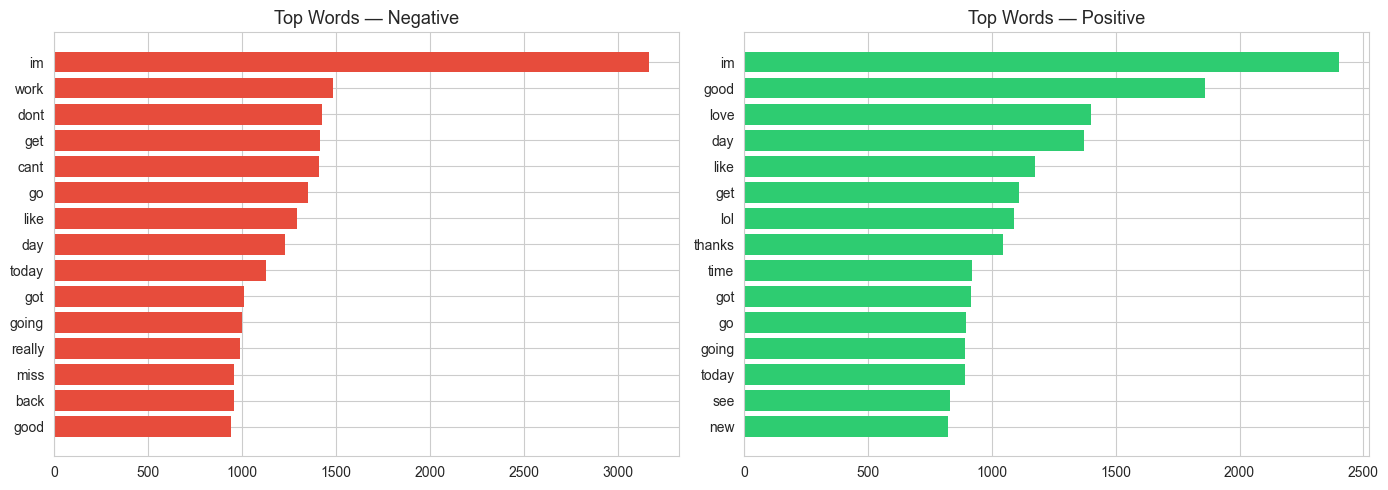

In [10]:
def get_top_words(series, n=20, remove_stopwords=True):
    """Return top n words from a series of text."""
    all_words = []
    for text in series.dropna():
        tokens = str(text).lower().split()
        tokens = [re.sub(r'[^a-z]', '', w) for w in tokens]
        tokens = [w for w in tokens if len(w) > 1]
        if remove_stopwords:
            tokens = [w for w in tokens if w not in STOP_WORDS]
        all_words.extend(tokens)
    return Counter(all_words).most_common(n)

# Top words per sentiment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label, color) in zip(axes, zip(['Negative', 'Positive'], colors)):
    subset = df[df['sentiment_label'] == label]['text']
    top = get_top_words(subset, n=15)
    words, counts = zip(*top)
    ax.barh(list(reversed(words)), list(reversed(counts)), color=color, edgecolor='none')
    ax.set_title(f'Top Words — {label}', fontsize=13)

plt.tight_layout()
plt.show()

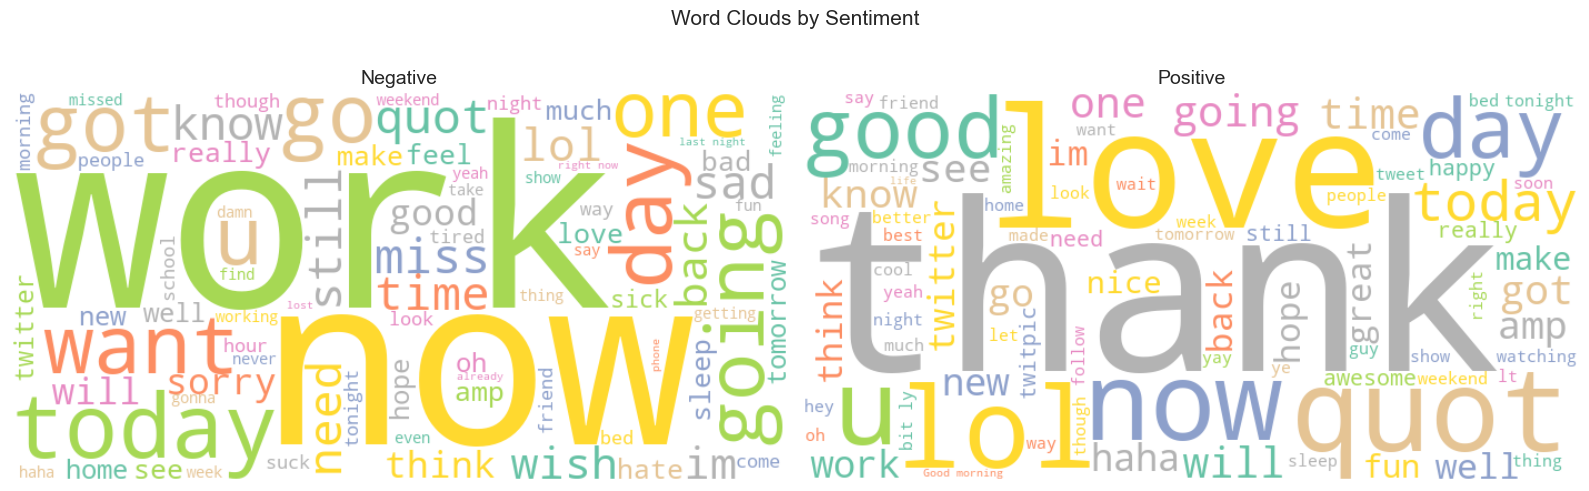

In [11]:
# Word clouds per sentiment
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, label in zip(axes, ['Negative', 'Positive']):
    text = ' '.join(df[df['sentiment_label'] == label]['text'].dropna().astype(str))
    wc = WordCloud(width=700, height=350, background_color='white',
                   max_words=80, colormap='Set2').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(label, fontsize=14)
    ax.axis('off')

plt.suptitle('Word Clouds by Sentiment', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# Words unique to each sentiment (appear much more in one vs the other)
neg_words = dict(get_top_words(df[df['sentiment_label'] == 'Negative']['text'], n=100))
pos_words = dict(get_top_words(df[df['sentiment_label'] == 'Positive']['text'], n=100))

# Ratio: how much more frequent a word is in one class vs the other
all_keys = set(neg_words) | set(pos_words)
ratios = []
for w in all_keys:
    n = neg_words.get(w, 1)
    p = pos_words.get(w, 1)
    ratios.append((w, p / n))

ratios.sort(key=lambda x: x[1])
print('Most "Negative" words (low pos/neg ratio):')
for w, r in ratios[:10]:
    print(f'  {w:15s}  ratio: {r:.2f}')

print('\nMost "Positive" words (high pos/neg ratio):')
for w, r in ratios[-10:]:
    print(f'  {w:15s}  ratio: {r:.2f}')

Most "Negative" words (low pos/neg ratio):
  miss             ratio: 0.00
  sad              ratio: 0.00
  bad              ratio: 0.00
  wish             ratio: 0.00
  sorry            ratio: 0.00
  didnt            ratio: 0.00
  hate             ratio: 0.00
  sick             ratio: 0.00
  school           ratio: 0.00
  tired            ratio: 0.00

Most "Positive" words (high pos/neg ratio):
  everyone         ratio: 333.00
  yes              ratio: 371.00
  best             ratio: 385.00
  hey              ratio: 435.00
  youre            ratio: 446.00
  awesome          ratio: 449.00
  thank            ratio: 479.00
  nice             ratio: 509.00
  happy            ratio: 659.00
  thanks           ratio: 1044.00


---
## 5. Temporal Analysis

In [13]:
df['date_parsed'] = pd.to_datetime(df['date'], format='mixed', errors='coerce')
df['hour'] = df['date_parsed'].dt.hour
df['day_of_week'] = df['date_parsed'].dt.day_name()
df['month'] = df['date_parsed'].dt.month_name()

print(f'Date range: {df["date_parsed"].min()} — {df["date_parsed"].max()}')
print(f'Rows with valid dates: {df["date_parsed"].notna().sum():,}')

Date range: NaT — NaT
Rows with valid dates: 0


TypeError: no numeric data to plot

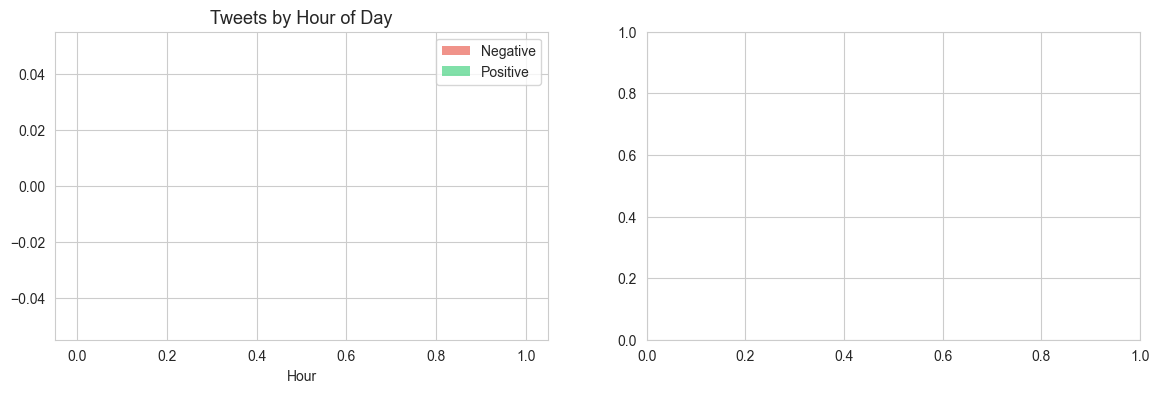

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Tweets by hour
for label, color in zip(['Negative', 'Positive'], colors):
    subset = df[df['sentiment_label'] == label]
    subset['hour'].dropna().hist(bins=24, alpha=0.6, ax=axes[0], color=color,
                                 label=label, edgecolor='none')
axes[0].set_title('Tweets by Hour of Day', fontsize=13)
axes[0].set_xlabel('Hour')
axes[0].legend()

# Tweets by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_sent = df.groupby(['day_of_week', 'sentiment_label']).size().unstack(fill_value=0)
day_sent = day_sent.reindex(day_order)
day_sent.plot(kind='bar', ax=axes[1], color=colors, edgecolor='none')
axes[1].set_title('Tweets by Day of Week', fontsize=13)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

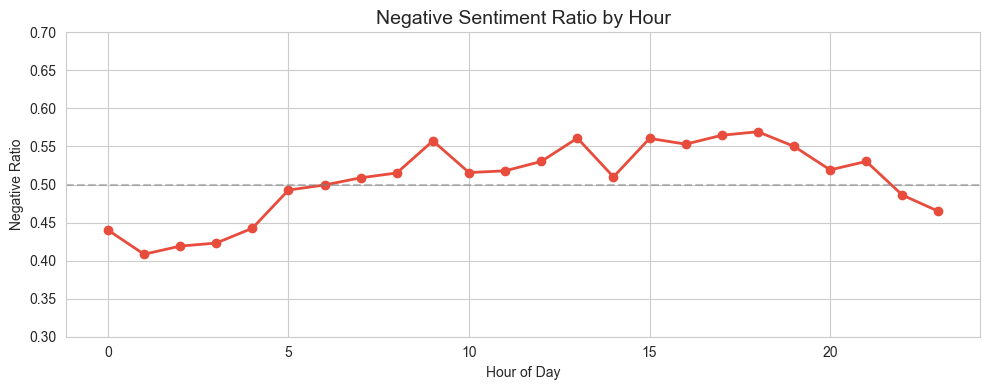

In [ ]:
# Sentiment ratio by hour — is there a time of day when people are more negative?
hourly = df.groupby(['hour', 'sentiment_label']).size().unstack(fill_value=0)
hourly['neg_ratio'] = hourly['Negative'] / (hourly['Negative'] + hourly['Positive'])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hourly.index, hourly['neg_ratio'], marker='o', color='#e74c3c', linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Negative Sentiment Ratio by Hour', fontsize=14)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Negative Ratio')
ax.set_ylim(0.3, 0.7)
plt.tight_layout()
plt.show()

---
## 6. User Activity Analysis

Unique users in sample: 44,653
Avg tweets per user: 1.1
Max tweets by one user: 22


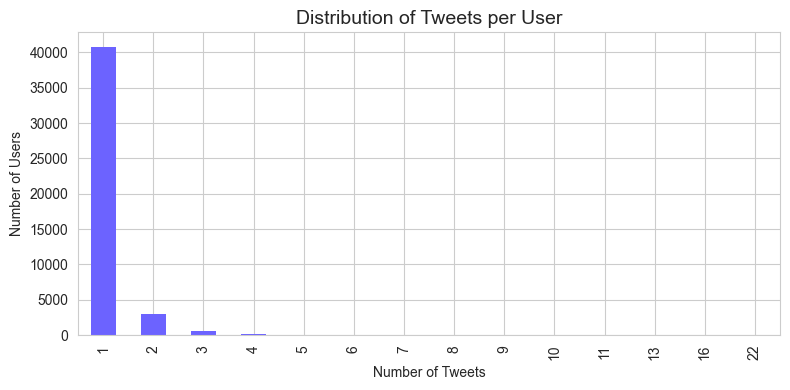

In [ ]:
# How many tweets per user in the sample?
user_counts = df['user'].value_counts()
print(f'Unique users in sample: {len(user_counts):,}')
print(f'Avg tweets per user: {user_counts.mean():.1f}')
print(f'Max tweets by one user: {user_counts.max()}')

fig, ax = plt.subplots(figsize=(8, 4))
user_counts.value_counts().sort_index().head(20).plot(kind='bar', ax=ax,
    color='#6C63FF', edgecolor='none')
ax.set_title('Distribution of Tweets per User', fontsize=14)
ax.set_xlabel('Number of Tweets')
ax.set_ylabel('Number of Users')
plt.tight_layout()
plt.show()

---
## 7. Preprocessing

The following steps are applied to each tweet:

| Step | Tool/Method | Description |
|------|------------|-------------|
| 1 | `str.lower()` | Convert to lowercase |
| 2 | `re.sub()` | Remove URLs |
| 3 | `re.sub()` | Remove @mentions |
| 4 | `re.sub()` | Remove RT prefix |
| 5 | `re.sub()` | Remove HTML entities (&amp; etc.) |
| 6 | `str.replace()` | Remove # symbol (keep word) |
| 7 | `re.sub()` | Remove punctuation & special characters |
| 8 | `re.sub()` | Remove extra whitespace |
| 9 | `nltk.word_tokenize()` | Tokenization |
| 10 | `nltk.stopwords` | Remove English stopwords |
| 11 | `WordNetLemmatizer` | Lemmatization |

In [ ]:
def preprocess_tweet(text):
    """Full preprocessing pipeline for a single tweet."""
    text = str(text)
    # 1. Lowercase
    text = text.lower()
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # 3. Remove mentions (@user)
    text = re.sub(r'@\w+', '', text)
    # 4. Remove RT prefix
    text = re.sub(r'^rt\s+', '', text)
    # 5. Remove HTML entities (&amp; etc.)
    text = re.sub(r'&\w+;', '', text)
    # 6. Remove hashtag symbol (keep the word)
    text = text.replace('#', '')
    # 7. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    # 8. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # 9. Tokenize
    tokens = word_tokenize(text)
    # 10. Remove stopwords
    tokens = [w for w in tokens if w not in STOP_WORDS and len(w) > 1]
    # 11. Lemmatize
    tokens = [LEMMATIZER.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

# Show examples before & after
print('=== Preprocessing Examples ===')
for i in [0, 1, 5, 100]:
    original = str(df.iloc[i]['text'])
    cleaned = preprocess_tweet(original)
    print(f'\nOriginal:  {original[:120]}')
    print(f'Cleaned:   {cleaned[:120]}')
    print('-' * 60)

=== Preprocessing Examples ===

Original:  @xnausikaax oh no! where did u order from? that's horrible 
Cleaned:   oh order thats horrible
------------------------------------------------------------

Original:  A great hard training weekend is over.  a couple days of rest and lets do it again!  Lots of computer time to put in now
Cleaned:   great hard training weekend couple day rest let lot computer time put
------------------------------------------------------------

Original:  @xPowxBangxBoomx dammiitt!! i wish i had MTV 
Cleaned:   dammiitt wish mtv
------------------------------------------------------------

Original:  Fast Food For Lunch! 
Cleaned:   fast food lunch
------------------------------------------------------------


In [ ]:
# Apply preprocessing to all tweets in the sample
df['text_clean'] = df['text'].apply(preprocess_tweet)

# Check for empty tweets after cleaning
empty_count = (df['text_clean'].str.strip() == '').sum()
print(f'Empty tweets after cleaning: {empty_count}')

df['clean_word_count'] = df['text_clean'].apply(lambda x: len(x.split()) if x.strip() else 0)

print(f'\nBefore preprocessing — avg words per tweet: {df["word_count"].mean():.1f}')
print(f'After preprocessing  — avg words per tweet: {df["clean_word_count"].mean():.1f}')

df[['text', 'text_clean', 'sentiment_label']].head(10)

Empty tweets after cleaning: 236

Before preprocessing — avg words per tweet: 13.1
After preprocessing  — avg words per tweet: 7.0


,text,text_clean,sentiment_label
0,@xnausikaax oh no! where did u order from? tha...,oh order thats horrible,Negative
1,A great hard training weekend is over. a coup...,great hard training weekend couple day rest le...,Negative
2,"Right, off to work Only 5 hours to go until I...",right work hour go im free xd,Negative
3,I am craving for japanese food,craving japanese food,Negative
4,Jean Michel Jarre concert tomorrow gotta work...,jean michel jarre concert tomorrow got ta work...,Negative
5,@xPowxBangxBoomx dammiitt!! i wish i had MTV,dammiitt wish mtv,Negative
6,@Rohan_01 You know..it's really sad that u kno...,knowits really sad know ur classmate dont care...,Negative
7,@FaketragedyCom i know,know,Negative
8,@JudahGabriel i wish i had that much to say,wish much say,Negative
9,"ow, i can't move my neck or my back hurts to...",ow cant move neck back hurt much dont know,Negative


---
## 8. Vectorization — TF-IDF

We convert the cleaned text into a numerical vector representation using **TF-IDF** (Term Frequency — Inverse Document Frequency) with unigrams and bigrams.

In [ ]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df['text_clean'])

print(f'TF-IDF matrix shape: {X_tfidf.shape}')
print(f'  Rows (tweets): {X_tfidf.shape[0]:,}')
print(f'  Features (terms): {X_tfidf.shape[1]:,}')
print(f'  Sparsity: {1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]):.4%}')

TF-IDF matrix shape: (50000, 5000)
  Rows (tweets): 50,000
  Features (terms): 5,000
  Sparsity: 99.8706%


In [ ]:
# Top TF-IDF terms per sentiment
print('Top 10 TF-IDF terms per sentiment:')
feature_names = tfidf.get_feature_names_out()
for sent_val, sent_name in [(0, 'Negative'), (4, 'Positive')]:
    mask = (df['sentiment'] == sent_val).values
    mean_tfidf = np.asarray(X_tfidf[mask].mean(axis=0)).flatten()
    top_idx = mean_tfidf.argsort()[-10:][::-1]
    top_terms = [(feature_names[i], mean_tfidf[i]) for i in top_idx]
    print(f'\n  {sent_name}:')
    for term, score in top_terms:
        print(f'    {term:20s} {score:.4f}')

Top 10 TF-IDF terms per sentiment:

  Negative:
    im                   0.0225
    work                 0.0158
    dont                 0.0132
    miss                 0.0132
    day                  0.0132
    cant                 0.0130
    go                   0.0125
    get                  0.0120
    want                 0.0115
    today                0.0111

  Positive:
    good                 0.0184
    im                   0.0176
    love                 0.0171
    thanks               0.0161
    day                  0.0145
    lol                  0.0119
    like                 0.0114
    time                 0.0104
    got                  0.0099
    get                  0.0099


---
## Summary

| Property | Value |
|----------|-------|
| Dataset | `training.1600000.processed.noemoticon.csv` (Sentiment140) |
| Source | Twitter |
| Total samples | 1,600,000 (EDA on 50K balanced sample) |
| Classes | 2 (Negative / Positive) |
| Balanced? | Yes — 800K per class |
| Labeling method | Auto-labeled from emoticons (distant supervision) |
| Preprocessing | Lowercase, remove URLs/mentions/RT/HTML/punctuation, tokenize, stopwords, lemmatize |
| Vectorization | TF-IDF (5,000 features, unigrams + bigrams) |
| Output format | Sparse TF-IDF matrix — ready for ML models |

**Key characteristics:**
- Very large dataset — enough data for deep learning approaches
- Perfectly balanced classes — no need for sampling strategies
- Labels are auto-generated (noisy) — may affect model ceiling